Columns: ['Wavelength', 'Diatom_Ptricornutum', 'Diatom_Csimplex', 'Chlamydomonas_Cpriscuii', 'Chlamydomonas_Creindhardtii', 'Dinoflagellate_Symbiodiniumsp', 'Dinoflagellate_Smicroadriaticum', 'Dinoflagellate_Dtrenchii', 'Dinoflagellate_Cgoreaui', 'Cyanobacteria_Synechosystis']
   Wavelength  Diatom_Ptricornutum  Diatom_Csimplex  Chlamydomonas_Cpriscuii  \
0         800                  0.0              0.0                      0.0   
1         799                  0.0              0.0                      0.0   
2         798                  0.0              0.0                      0.0   
3         797                  0.0              0.0                      0.0   
4         796                  0.0              0.0                      0.0   

   Chlamydomonas_Creindhardtii  Dinoflagellate_Symbiodiniumsp  \
0                          0.0                      -0.000045   
1                          0.0                       0.004540   
2                          0.0                

/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/Project/machine_learning/linear_combination.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mixtures_df[mix_col_name] = mix_spectrum
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/Project/machine_learning/linear_combination.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mixtures_df[mix_col_name] = mix_spectrum
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - M

Mixture spectra saved to: Spectral_library_with_mixtures.xlsx
Mixture weights saved to: Spectral_library_mixture_weights.xlsx
Spectra columns example: Index(['Wavelength', 'Diatom_Ptricornutum', 'Diatom_Csimplex',
       'Chlamydomonas_Cpriscuii', 'Chlamydomonas_Creindhardtii',
       'Dinoflagellate_Symbiodiniumsp', 'Dinoflagellate_Smicroadriaticum',
       'Dinoflagellate_Dtrenchii', 'Dinoflagellate_Cgoreaui',
       'Cyanobacteria_Synechosystis',
       'mix2_Diatom_Ptricornutum_Diatom_Csimplex_0',
       'mix2_Diatom_Ptricornutum_Diatom_Csimplex_1',
       'mix2_Diatom_Ptricornutum_Diatom_Csimplex_2',
       'mix2_Diatom_Ptricornutum_Diatom_Csimplex_3',
       'mix2_Diatom_Ptricornutum_Diatom_Csimplex_4'],
      dtype='object')
Weights head:
                                 mixture_name  Diatom_Ptricornutum  \
0  mix2_Diatom_Ptricornutum_Diatom_Csimplex_0             0.507174   
1  mix2_Diatom_Ptricornutum_Diatom_Csimplex_1             0.894994   
2  mix2_Diatom_Ptricornutum_Diatom

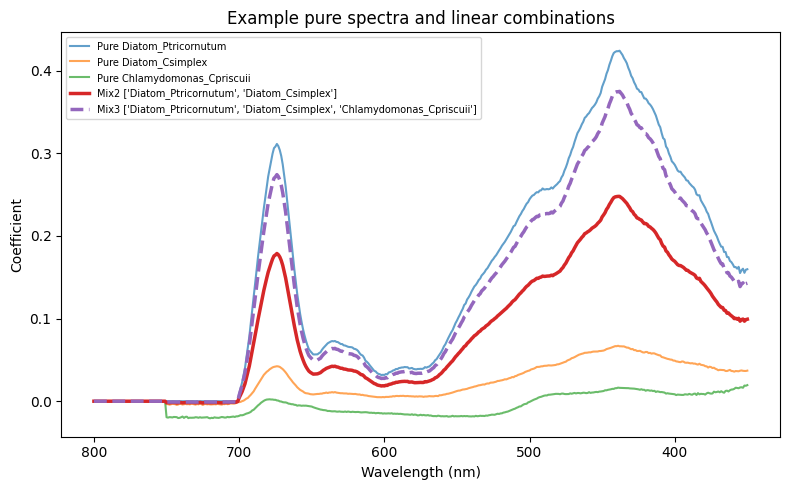

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from linear_combination import *

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

# Preferably use a GPU instead of CPU
print(f"PyTorch version: {torch.__version__}")
# --- Auto-detect GPU (CUDA or Apple MPS) — falls back to CPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

In [2]:
path = "Spectral_library_clean.xlsx"
df_clean = pd.read_excel(path)

# Keep a version with NaNs as the "truth"
df_truth = df_clean.copy()

# For building linear combinations, we usually set NaN -> 0
df_for_mix = df_clean.fillna(0)
wavelength = df_for_mix['Wavelength']
print(df_for_mix.shape)

(451, 10)


In [3]:
def data_creation_CNN(noise_level):
    '''This function outputs a noisy absorption spectrum, normalized with mean and standard deviation.'''
    mixture_spectra_full, weights_spectra = generate_mixture_spectra(df_for_mix)
    mixture_spectra_full = mixture_spectra_full.to_numpy()

    weight_values = weights_spectra.drop(columns="mixture_name").to_numpy(dtype=float) # shape (600,9) (samples, species)
    mixture_spectra = mixture_spectra_full[:,10:].astype(float).T # shape (600, 451)(samples, wavelengths)
    number_of_samples, _ = mixture_spectra.shape
    
    X = torch.tensor(mixture_spectra, dtype=torch.float32) + noise_level * torch.randn(mixture_spectra.shape)
    y = torch.tensor(weight_values, dtype = torch.float32)

    perm = torch.randperm(X.shape[0])

    X, y = X[perm], y[perm]

    # separate into training and validation data
    N_training = int(number_of_samples * .8)
    # N_validation = int(number_of_samples * .2)

    # compute stats on training portion only
    mean = X[:N_training].mean(dim=0)
    std  = X[:N_training].std(dim=0) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets
    X_train_, y_train_ = X_norm[:N_training],  y[:N_training]
    X_val_,   y_val_   = X_norm[N_training:],  y[N_training:]
    return X_train_, y_train_, X_val_, y_val_

In [4]:
class CNN_1D(nn.Module):
    def __init__(self, num_classes=9):
        # if we need more blocks, we can consider ResNet style CNN!
        super().__init__()
        self.net = nn.Sequential(
        # block 1
        nn.Conv1d(1, 32, kernel_size=11, padding=5),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.MaxPool1d(2),

        # block 2
        nn.Conv1d(32, 64, kernel_size=7, padding=3),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.MaxPool1d(2),

        # block 3
        nn.Conv1d(64, 128, kernel_size=5, padding=2),
        nn.BatchNorm1d(128),
        nn.ReLU(),

        nn.Flatten(),
        nn.Linear(128 * (len(wavelength) // 4), num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
def training_loop(nr_epochs, X_train_, y_train_, X_val_, y_val_):
    model = CNN_1D()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    X_train_ = X_train_.unsqueeze(1)  # [batch, 1, (len wavelengths)] 
    X_val_ = X_val_.unsqueeze(1)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs   = []

    epochs_list = []

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_).squeeze() # same shape as y_train
        loss = nn.CrossEntropyLoss()(pred[:], y_train_)
        loss.backward()
        optimizer.step()
        prob = torch.softmax(pred, dim = 1)



        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_).squeeze() # same shape as y_val
            loss_val = nn.CrossEntropyLoss()(pred_val[:], y_val_)

            prob_val = torch.softmax(pred_val, dim=1)
            
        # if true, we return a 1. Else 0.
        train_acc = 100 * torch.mean(torch.abs(y_train_ - prob) / y_train_)
        val_acc = 100 * torch.mean(torch.abs(y_val_ - prob_val) / y_val_)

        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        train_accs.append(train_acc)
        val_accs.append(val_acc) 
        epochs_list.append(epoch)
    return train_losses, val_losses, train_accs, val_accs, epochs_list


In [ ]:
X_train, y_train, X_val, y_val = data_creation_CNN(0)
train_losses, val_losses, train_accs, val_accs, epochs_list = training_loop(300, X_train, y_train, X_val, y_val)

/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/Project/machine_learning/linear_combination.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mixtures_df[mix_col_name] = mix_spectrum
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/Project/machine_learning/linear_combination.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mixtures_df[mix_col_name] = mix_spectrum
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - M

tensor([0.0962, 0.0000, 0.0000, 0.2460, 0.6578, 0.0000, 0.0000, 0.0000, 0.0000])
tensor([0.1852, 0.0000, 0.0000, 0.4330, 0.0000, 0.0000, 0.0000, 0.0000, 0.3818])


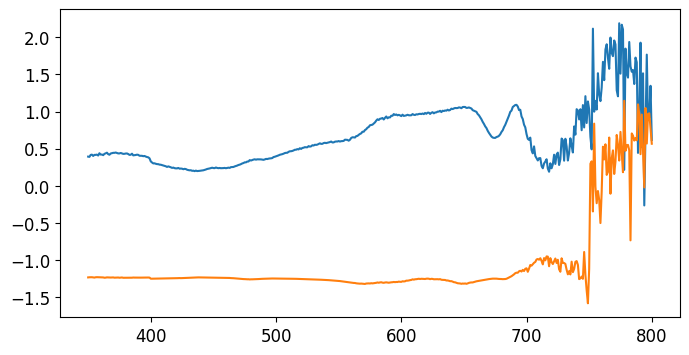

In [7]:
# to give a feel for the data
print(y_train[0, :])
print(y_train[-1, :])
plt.plot(wavelength, X_train[0,:])
plt.plot(wavelength, X_train[-10, :])
plt.show()

/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/Project/machine_learning/linear_combination.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mixtures_df[mix_col_name] = mix_spectrum
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - MSc AMEP/Semester 2/Machine Learning/Project/machine_learning/linear_combination.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mixtures_df[mix_col_name] = mix_spectrum
/Users/jochem1411/Library/CloudStorage/OneDrive-UvA/Year 1 - M

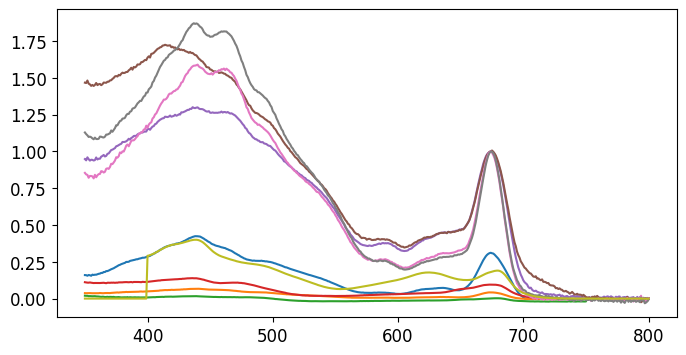

In [8]:
# to give an intuition on how all the 'pure' spectra look like
mixture_spectra_full, weights_spectra = generate_mixture_spectra(df_for_mix)
mixture_spectra_full = mixture_spectra_full.to_numpy()
mixture_spectra = mixture_spectra_full.astype(float).T # shape (600, 451)(samples, wavelengths)
for pure in mixture_spectra[1:10, :]:
    plt.plot(wavelength, pure)